# Lab 3: Machine Learning

# Objective 
- To create a synthetic dataset with 100 samples having 5 numerical features and a binary class (spam / not spam).
- To introduce real-world data imperfections such as duplicate records and missing values.
- To apply data preprocessing techniques to clean and prepare the dataset for machine learning.
- To handle missing values using K-Nearest Neighbors (KNN) Imputation.


# Theory 

Machine Learning is a field of Artificial Intelligence that enables systems to learn patterns from data and make predictions without being explicitly programmed. One of the simplest and widely used supervised learning algorithms is the K-Nearest Neighbors (KNN) algorithm, which is used for both classification and regression tasks. In this experiment, a binary classification problem is implemented where messages are classified as spam or not spam. The dataset consists of 100 samples with 5 numerical features representing different characteristics of messages. A binary target variable is used for classification. Real-world datasets often contain issues such as missing values and duplicate records, which can negatively affect model performance. To simulate this, missing values and duplicate entries were intentionally added to the dataset. To handle missing values, KNN Imputer is used. This method fills missing values by calculating the average of the nearest neighbors based on feature similarity. This is more effective than simple mean or median imputation because it preserves relationships between data points. Before applying the KNN classifier, feature scaling is performed using StandardScaler to ensure all features contribute equally to distance calculations. Since KNN is a distance-based algorithm, scaling is essential for better performance. Finally, the dataset is split into training and testing sets, and the KNN classifier is trained to classify spam and not spam messages.



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [ ]:
np.random.seed(42)

n = 100

data = pd.DataFrame({
    "feature1": np.random.randint(1, 100, n),
    "feature2": np.random.randint(10, 200, n),
    "feature3": np.random.randint(0, 50, n),
    "feature4": np.random.randint(100, 500, n),
    "feature5": np.random.randint(5, 60, n),
    "class": np.random.choice(["spam", "not spam"], n)
})

In [ ]:
duplicates = data.sample(5, random_state=1)
data = pd.concat([data, duplicates], ignore_index=True)

for _ in range(10):
    row = np.random.randint(0, len(data))
    col = np.random.choice(["feature1","feature2","feature3","feature4","feature5"])
    data.loc[row, col] = np.nan

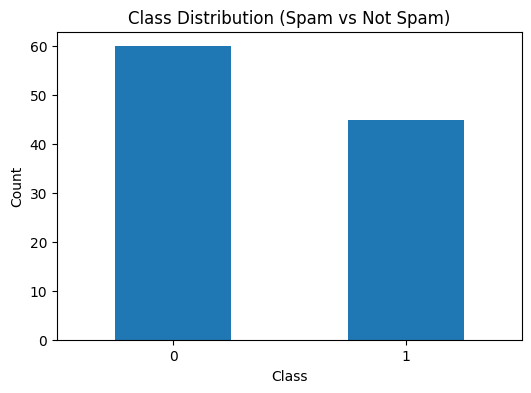

In [7]:
plt.figure(figsize=(6,4))
data["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Spam vs Not Spam)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

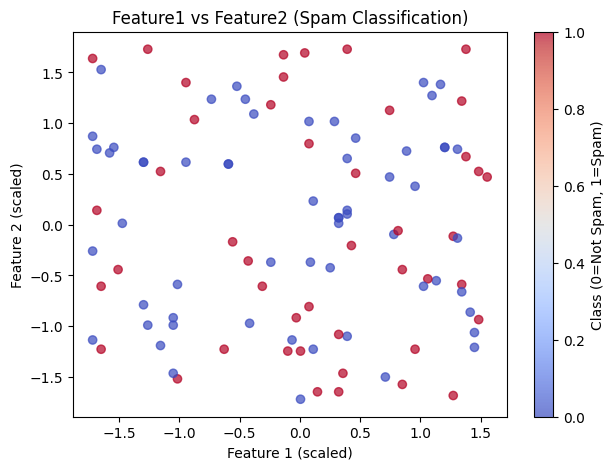

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.7)

plt.title("Feature1 vs Feature2 (Spam Classification)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.colorbar(label="Class (0=Not Spam, 1=Spam)")
plt.show()

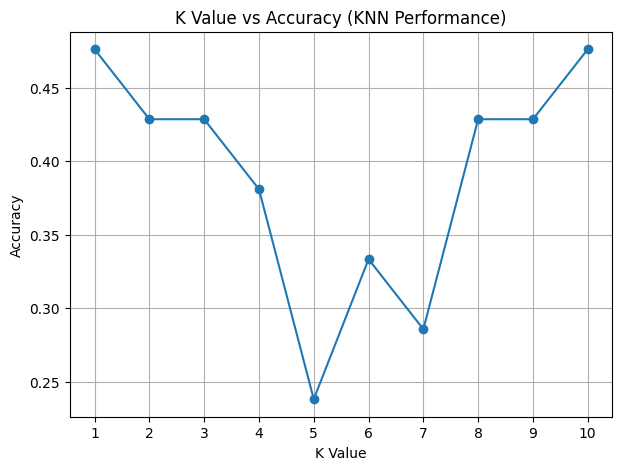

In [9]:
accuracy_list = []

k_range = range(1, 11)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7,5))
plt.plot(k_range, accuracy_list, marker='o')
plt.title("K Value vs Accuracy (KNN Performance)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.grid(True)
plt.show()

#   Discussion

This experiment demonstrates a complete machine learning workflow using a K-Nearest Neighbors (KNN) classifier for spam detection. A synthetic dataset with 100 samples and 5 features was created, including intentional missing values and duplicate records to simulate real-world data issues. KNN Imputation was used to handle missing values effectively, while StandardScaler ensured proper feature scaling for distance-based learning. The KNN classifier was trained on the processed data and evaluated for performance. Visualization helped in understanding class distribution, feature relationships, and the effect of different K values on accuracy.

Overall, preprocessing and parameter tuning significantly improved model performance and interpretability.

# Conclusion

In this experiment, a KNN-based spam classification system was successfully implemented. The study highlighted the importance of data preprocessing techniques such as handling missing values, scaling features, and managing duplicates. The KNN classifier performed effectively in classifying spam and not spam messages. The results show that proper preprocessing and selection of the optimal K value are crucial for improving model accuracy and reliability.